## Evaluating Topic Category Predictions by GPT

### Assumptions
1. Common metrics (Jaccard similarity, Precision, Recall, F-score) will be insufficient for evaluation as they do not take into consideration conceptual hierarchies and conceptual similarity
2. An adjusted metric will be necessary to appropriately evaluate GPT's performance on this task
3. This metric will not be meaningful unless it can be compared to the same metrics applied to the classifications performed by two different curators

### Approach
#### For the initial evaluation (Feasibility check)
1. Identify thematic / domain-specific repositories and assign three appropriate topic categories
2. Run GPT classifications on all the repositories and evaluate GPT performance based on the adjusted metrics to check feasibility of leveraging GPT for this task.

#### For the quality evaluation
1. Conduct a reasonable random sampling of the available records
    a. This sampling will consist of a random set of 10% of the number of records in the repository with a 25 record max (for really large repositories). It will only have the identifier, source, name, and description of the record. No other metadata will be available to either the curators or GPT.
    b. Curator A will classify all the records in this "full" sample set with accordance to the curation rules. 
    c. Curator B will classify a random subset of this sampling (75 records max) with accordance to the same rules.
2. GPT will be used to classify the records in the "full" sample set
3. Based on the adjusted metrics, compare the 75 records in common between Curator A and B for interrater metrics
4. Based on the adjusted metrics, compare the full record set of GPT classifications against Curator A.
5. Compare how GPT performs against Curator A vs how Curator B performs against Curator A.
    a. Subset by repository for additional evaluations to see how GPT compares with itself based on the record source

### Curation Rules
1. Does the name & description of the record provide sufficient information to identify at least one topicCategory?
  If not, write: 'Cannot be determined'
  Example: "Dataset MSV000081917 is currently private. It has been deposited to MassIVE, but has not yet been publicly released.", There is a dataset, but there is not enough information to identify ANY sort of topic

2. If one or more topic(s) can be identified, are they within within EDAM (i.e. life sciences domain?). Note we are using the latest (unstable) version of EDAM Topics, viewable at: https://edamontology.github.io/edam-browser/#topic_0003&version=latest
  If not, write: 'terms not in EDAMT'
  Example: "Replication Data for: The Politics of Accountability in Supreme Court Nominations: Voter Recall and Assessment of Senator Votes on Nominees", relevant topics would be Political Science (which is NOT in EDAM)

3. If one or more topic(s) can be identified within EDAM Topics, please select the three most relevant topics (as specifically as possible)
  Example: https://data.niaid.nih.gov/resources?id=accessclinicaldata_NCT04283461
    Select: "Preclinical and clinical studies" (more specific) over "Medicines research and development"(less specific) or "Biomedical Science"(broad)
    Select: "Vaccinology"(most specific) over "Medicines research and development"(less specific) or "Biomedical Science"(broad)
    Select: "Safety sciences" (more specific) over "Medicines research and development"(less specific) or "Biomedical Science"(broad)

Latest version of EDAM Topics in the EDAM Browser
https://edamontology.github.io/edam-browser/#topic_0003&version=latest
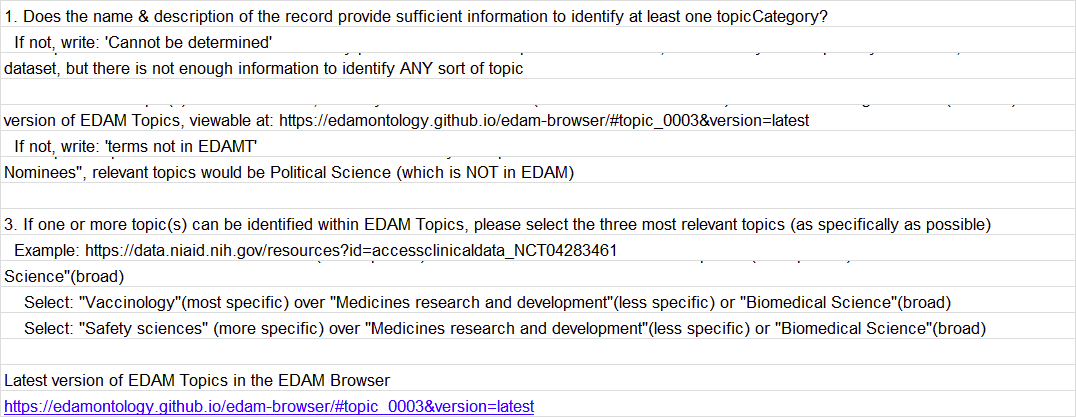


### Evaluation Metrics
Currently, The J-sim, R, and P are low between the ground truth and GPT predictions due to GPT being more precise or more broad in its selection of terms

We need a systematic evaluation metrics to compare the results without having to constantly manually run them

#### The Approach:
1. Identify the exact matches between the two classifications (eg between predicted and curated or between curator A and curator B)
2. Check if the predicted (or curator A) term is within the same tree as the primary curator's term
3. If two terms are within the same tree:
    * Treat the two terms as a match
    * Determine which term is closer to the root (http://edamontology.org/topic_0003)
        - Calculate a weight to apply depending on how close the closest term is to the root (Weight 1)
          - If closest term is one step away from root it should have a lower score than a closest term that is 2 steps away. This is to lower the weight of excessively generic terms (use: 1-(1/(# of steps to closest term))
        - Calculate a weight to apply depending on the number of steps between the two 'matching' terms (Weight 2)
            - If the closest term to root is the ground truth term, use: (1/(# of steps between the terms))
            - If the closest term to root is the prediction term, use: -(1/(# of steps between the terms)): It is negative only to ensure we will later be able to inspect the directionality
        - The overall weight should be a combination of the two, for example:
            - Overall weight = Weight 1 + ABS(Weight 2)

### Calculating the conceptual similarity scores

#### Calculating the simple weighted similarity score
This is a straightforward metric with a strong bias for exact matches
1. After removing the exact matches, perform pairwise matches, calculating the weight for each match
2. simple weighted similarity = Add the overall weight for all matches and divide by the total number of matches, then add the j-sim (since we previously removed exact matches)
    * This method essentially averages the weighted similarity across all pairwise matches and *then* adds back the J-sim values since exact matches were removed). This approach thus gives a much higher score for records with exact matches

#### Calculating the conceptual similarity score
This similarity score includes the exact matches prior to averaging out the results of all the pairwise matches 
1. After removing the exact matches, perform pairwise matches, calculating the weight for each match
2. Conceptual similarity score = Add the overall weight for all the pairwise matches to the number of exact matches *then* divide by the sum of the total number of pairwise matches and exact matches

#### Calculating the adjusted similarity score
This similarity score includes the exact matches in the pairwise combinations potentially diluting the value of an exact match
1. Adjusted similarity score = Add the overall weight for all pairwise matches (without removing exact matches) *then* divide by the total number of pairwise matches


### Additional adjustments and evaluations

**Adjusting for prediction number biases:**

- The weighted similarity will be advantageous to ChatGPT 4 due to its tendency to dump every relevant term
- To account for that, we can penalize it for making excessive guesses by multiplying the weighted similarity against the ratio of (# of gold standard terms)/max(# of gold standard terms),(# of predicted terms)).
  * If LLM guesses the same number of terms as # of gold standard, this ratio = 1: No penalty
  * If LLM guesses more terms than # of gold standard, this ratio >1: penalty, greater number, greater penalty
  
**Evaluating whether the prediction has a tendency to be more specific or less specific than the gold standard**

- Broadness evaluation: (# of positive Weight 2 values)/(# of negative Weight 2 values)
  - Number of times broader term is ground truth / Number of times broader term is predicted term
- If broadness evaluation is \>1, LLM model predictions are more specific than Ground truth/gold standard terms
  - If broadness evaluation is \<1, LLM model predictions are less specific than ground truth/gold standard terms



### Relevant Notebooks
#### The basic scripts
1. Topic_prep: This notebook prepares and formats the EDAM topics ontology for use
2. Basic_scripts: This notebook performs basic functions like importing and formatting the data, and running simple metrics
2. Interrater comparison: This runs the scripts on the set of curated records in common between the two curators
3. Topic evaluation: This runs the scripts on the GPT predictions against the primary curator


### Relevant Data
In /EDAM/ 
1. These are exports of the EDAM ontology

In /data/
1. "Repo-level GPT classifications": GPT Predictions for all records within repositories with clear thematic or domain specificity. 
2. "Subset Sample.tsv": A random sample of 75 records subsetted from the sample of records curated by the primary curator
3. "Curator classifications.xlsx": The classifications performed by the primary and secondary curators. Note, the curators performed these classifications independently in separate google spreadsheets and the data was copied into this single file.


In /result/
1. "interrater results.tsv": The comparison metrics between the two curators
2. "interrater_summary.json": The summary statistics of the metrics in the "interrater results.tsv" file
3. "topic_category_evaluation.tsv": ??????
